In [1]:
!pip install -q streamlit shap matplotlib seaborn scipy joblib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# MediTrack — Random Forest Module
### 30-Day Readmission Risk: Model, Explainability, Database, RAG Assistant, App

This notebook is your complete, self-contained submission for the **Random Forest** track of the MediTrack project (CP-02).

It mirrors the Gradient Boosting notebook's structure exactly — **Steps 1-4 (data cleaning, base-rate
analysis, feature engineering, train/test split) use identical code and produce the identical
99,343-row cleaned dataset**, so the two models are compared on the exact same data. Only Steps
5 onward (model, explainability, artifacts) differ.

It covers, in order:
1. Data cleaning & exclusion
2. Base rate & statistical analysis
3. Feature engineering
4. Train/test split & class imbalance
5. Train the Random Forest model
6. Decision threshold tuning
7. Patient-level explainability (SHAP)
8. High-risk cohort list
9. Relational database & SQL queries
10. RAG-style discharge assistant & safety guardrails
11. Save model artifacts
12. The MediTrack Streamlit application
13. Running & deploying the app


## Step 0 — Load Libraries & Data


In [2]:
# Step 1 — Load the Full Canonical Dataset
import pandas as pd
import numpy as np
import os

# Import shared preprocessing for canonical split & feature consistency
import sys
sys.path.insert(0, '.')
from shared_preprocessing import (
    get_classical_split, prepare_classical_features,
    FEATURES, OHE_COLUMNS, MEDICATION_COLS
)

data_path = 'diabetic_data.csv'
if not os.path.exists(data_path):
    data_path = '../diabetic_data.csv'

df = pd.read_csv(data_path)
print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Step 1 — Data Cleaning & Exclusion Rules

**What we do:** remove deceased/hospice discharges (they had no chance of being readmitted),
drop columns that are almost entirely missing (`weight`, `payer_code`, `medical_specialty`),
and convert the 3-class `readmitted` column into the binary target the brief requires.

**Identical to the Gradient Boosting notebook** — this is the shared dataset both models are
evaluated on.


In [3]:
# discharge_disposition_id 11, 13, 14, 19, 20, 21 = expired / hospice
EXCLUDE_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

df_clean = df[~df['discharge_disposition_id'].isin(EXCLUDE_DISCHARGE_IDS)].copy()
print(f"Shape after excluding deceased/hospice discharges: {df_clean.shape}")

# weight is ~97% missing, payer_code ~40% missing, medical_specialty ~49% missing.
# Documented decision: drop rather than impute, since imputing that much data
# would manufacture information we don't have.
df_clean.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Binary target: 1 = readmitted within 30 days, 0 = not readmitted / readmitted later
df_clean['risk_target'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean.drop(columns=['readmitted'], inplace=True)

print("\nTarget distribution:")
print(df_clean['risk_target'].value_counts())
print("\nPercentage:")
print((df_clean['risk_target'].value_counts(normalize=True) * 100).round(2))


Shape after excluding deceased/hospice discharges: (99343, 50)



Target distribution:
risk_target
0    88029
1    11314
Name: count, dtype: int64

Percentage:
risk_target
0    88.61
1    11.39
Name: proportion, dtype: float64


## Step 2 — Establishing the Base Rate & Statistical Analysis

The brief requires the readmission base rate to be established, and tested against
age group, admission type, and prior inpatient history, **with a statistical basis**
(not just a chart). Since all three variables are categorical/discrete, we use the
Chi-Square test of independence.


In [4]:
import scipy.stats as stats

base_rate = df_clean['risk_target'].mean() * 100
print(f"Overall 30-day readmission base rate: {base_rate:.2f}%\n")
print("=" * 55)

columns_to_test = {
    'Age Group': 'age',
    'Admission Type': 'admission_type_id',
    'Prior Inpatient History': 'number_inpatient',
}

chi_square_results = []
for label, col in columns_to_test.items():
    contingency_table = pd.crosstab(df_clean[col], df_clean['risk_target'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    significant = p_value < 0.05
    chi_square_results.append({'Variable': label, 'Chi2': round(chi2, 2), 'p-value': p_value, 'Significant (p<0.05)': significant})
    print(f"--- {label} ({col}) ---")
    print(f"Chi2 = {chi2:.2f}, p-value = {p_value:.2e}")
    print("Conclusion:", "STATISTICALLY SIGNIFICANT" if significant else "Not significant")
    print("-" * 55)

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df


Overall 30-day readmission base rate: 11.39%

--- Age Group (age) ---
Chi2 = 133.60, p-value = 2.15e-24
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------
--- Admission Type (admission_type_id) ---
Chi2 = 32.59, p-value = 3.16e-05
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------
--- Prior Inpatient History (number_inpatient) ---
Chi2 = 2882.47, p-value = 0.00e+00
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------


,Variable,Chi2,p-value,Significant (p<0.05)
0,Age Group,133.60,2.154572e-24,True
1,Admission Type,32.59,3.158305e-05,True
2,Prior Inpatient History,2882.47,0.000000e+00,True



icd9_official_descriptions = {
    '428': 'congestive heart failure left ventricular failure cardiac insufficiency',
    '414': 'coronary atherosclerosis chronic ischemic heart disease coronary artery disease',
    '786': 'symptoms involving respiratory system chest pain dyspnea shortness of breath',
    '410': 'acute myocardial infarction heart attack coronary thrombosis',
    '486': 'pneumonia organism unspecified lower respiratory tract infection',
    '427': 'cardiac dysrhythmias atrial fibrillation flutter heart rhythm disorder',
    '491': 'chronic bronchitis chronic obstructive pulmonary disease copd',
    '715': 'osteoarthrosis osteoarthritis degenerative joint disease',
    '682': 'other cellulitis and abscess acute skin infection',
    '434': 'occlusion of cerebral arteries acute ischemic stroke cerebrovascular accident',
    '276': 'disorders of fluid electrolyte and acid base balance dehydration hyponatremia',
    '250': 'diabetes mellitus with vascular manifestations uncontrolled blood glucose hyperosmolality',
    '401': 'essential primary hypertension high blood pressure',
    '496': 'chronic airway obstruction not elsewhere classified copd lung disease',
    '599': 'urinary tract infection kidney urethra bladder inflammation',
    '403': 'hypertensive chronic kidney disease renal disease',
    '411': 'other acute and subacute forms of ischemic heart disease unstable angina',
    '585': 'chronic kidney disease renal failure end stage renal disease',
    '272': 'disorders of lipoid metabolism hyperlipidemia hypercholesterolemia'
}

## Step 3 — Feature Engineering

**Diagnosis grouping:** `diag_1`/`diag_2`/`diag_3` contain hundreds of raw ICD-9 codes.
Feeding these directly into the model would create unusable high-cardinality features,
so they are grouped into 9 clinically meaningful categories (Circulatory, Respiratory, etc.)

**Medication changes:** the 23 individual medication columns are consolidated into a single
count of how many medications were adjusted (`Up`/`Down`) during the encounter.


In [5]:

icd9_official_descriptions = {
    '428': 'congestive heart failure left ventricular failure cardiac insufficiency',
    '414': 'coronary atherosclerosis chronic ischemic heart disease coronary artery disease',
    '786': 'symptoms involving respiratory system chest pain dyspnea shortness of breath',
    '410': 'acute myocardial infarction heart attack coronary thrombosis',
    '486': 'pneumonia organism unspecified lower respiratory tract infection',
    '427': 'cardiac dysrhythmias atrial fibrillation flutter heart rhythm disorder',
    '491': 'chronic bronchitis chronic obstructive pulmonary disease copd',
    '715': 'osteoarthrosis osteoarthritis degenerative joint disease',
    '682': 'other cellulitis and abscess acute skin infection',
    '434': 'occlusion of cerebral arteries acute ischemic stroke cerebrovascular accident',
    '276': 'disorders of fluid electrolyte and acid base balance dehydration hyponatremia',
    '250': 'diabetes mellitus with vascular manifestations uncontrolled blood glucose hyperosmolality',
    '401': 'essential primary hypertension high blood pressure',
    '496': 'chronic airway obstruction not elsewhere classified copd lung disease',
    '599': 'urinary tract infection kidney urethra bladder inflammation',
    '403': 'hypertensive chronic kidney disease renal disease',
    '411': 'other acute and subacute forms of ischemic heart disease unstable angina',
    '585': 'chronic kidney disease renal failure end stage renal disease',
    '272': 'disorders of lipoid metabolism hyperlipidemia hypercholesterolemia'
}

def group_diagnosis(code):
    """Map a raw ICD-9 diagnosis code to one of 9 broad clinical categories."""
    if pd.isna(code):
        return 'Missing'
    if isinstance(code, str) and (code.startswith('V') or code.startswith('E')):
        return 'Other'
    try:
        code_num = float(code)
    except ValueError:
        return 'Other'

    if 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif code_num == 250:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

df_clean['primary_diagnosis_group'] = df_clean['diag_1'].apply(group_diagnosis)

MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
]

df_clean['num_medication_changes'] = df_clean[MEDICATION_COLS].apply(
    lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1
)

print("Feature engineering complete.")
print(df_clean['primary_diagnosis_group'].value_counts())


Feature engineering complete.
primary_diagnosis_group
Circulatory        29681
Other              26239
Respiratory        13934
Digestive           9333
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Diabetes             235
Name: count, dtype: int64


## Step 4 — Train/Test Split & Class Imbalance

Only ~11.4% of encounters are positive (readmitted within 30 days), so we need to
tell the model to pay more attention to that minority class.

**Justification for class weighting over resampling:** undersampling would throw away
~78,000 majority-class encounters, and oversampling (SMOTE) would manufacture synthetic
patients that don't correspond to real clinical presentations. Class weighting penalizes
the model for missing the minority class without inventing or discarding data.


In [6]:
# Step 4 — Canonical 3-way Stratified Split (64/16/20) & Class Imbalance
# Use shared canonical split to ensure IDENTICAL test set across LR/RF/GB/NB
from sklearn.model_selection import train_test_split

y = df_clean['risk_target']

# Canonical 3-way split: 64% train, 16% validation, 20% test
train_idx, val_idx, test_idx = get_classical_split(df_clean.index, y)

# One-hot encoding fitted on TRAINING DATA ONLY (prevents vocabulary leakage)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_classical_features(
    df_clean, train_idx, val_idx, test_idx
)

print('Train set shape:', X_train.shape, y_train.shape)
print('Val set shape:  ', X_val.shape, y_val.shape)
print('Test set shape: ', X_test.shape, y_test.shape)
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Val positive rate:   {y_val.mean():.4f}')
print(f'Test positive rate:  {y_test.mean():.4f}')
print(f'\nCanonical test encounters: {len(test_idx)}')
print(f'Class imbalance handled via class_weight="balanced" in model training')

Train set shape: (63579, 28) (63579,)
Val set shape:   (15895, 28) (15895,)
Test set shape:  (19869, 28) (19869,)
Train positive rate: 0.1139
Val positive rate:   0.1139
Test positive rate:  0.1139

Canonical test encounters: 19869
Class imbalance handled via class_weight="balanced" in model training


## Step 5 — Train the Random Forest Model

We use `RandomForestClassifier` with `class_weight='balanced'` (the bagging-ensemble
counterpart to Gradient Boosting's boosting approach) and evaluate with Recall, Precision,
F1 and ROC-AUC rather than accuracy — accuracy is misleading here, since predicting
"never readmitted" for everyone scores ~88.6% while catching zero true readmissions.

`n_estimators=300`, `max_depth=12`, `min_samples_leaf=5` were chosen to give the forest
enough trees to stabilize its probability estimates while capping depth so individual
trees don't overfit the 29-feature, ~79k-row training set.


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete.\n")

# Validation predictions (for threshold selection)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_proba)
print(f"Validation ROC-AUC: {val_roc_auc:.4f}")

# Test predictions (for FINAL evaluation only)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.50).astype(int)

print("=" * 50)
print("EVALUATION AT DEFAULT THRESHOLD (0.50) — FINAL TEST")
print("=" * 50)
print(classification_report(y_test, y_pred_default, digits=3))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("-" * 50)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

Training Random Forest model...


Training complete.

Validation ROC-AUC: 0.6367


EVALUATION AT DEFAULT THRESHOLD (0.50) — FINAL TEST
              precision    recall  f1-score   support

           0      0.911     0.757     0.827     17606
           1      0.183     0.424     0.256      2263

    accuracy                          0.719     19869
   macro avg      0.547     0.591     0.541     19869
weighted avg      0.828     0.719     0.762     19869

ROC-AUC Score: 0.6348
--------------------------------------------------
Confusion Matrix:
 [[13324  4282]
 [ 1303   960]]


## Step 6 — Decision Threshold Tuning (Clinical Justification)

The brief requires the threshold to be **explicitly tuned and defended**, not left at
the default 0.50. In healthcare, a **false negative** (discharging a high-risk patient
who is never flagged) is far more costly than a **false positive** (an unneeded follow-up
call), so we scan candidate thresholds and pick the point that best trades Recall against
alert fatigue — the same reasoning applied in the Gradient Boosting notebook.

We keep the **same 0.45 operating threshold** as the Gradient Boosting model so both
models are judged under identical clinical conditions, rather than each getting its
own best-case cutoff.


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# --- Threshold selection on VALIDATION data (not test) ---
threshold_candidates = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
rows = []
for t in threshold_candidates:
    preds = (y_val_proba >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Val Recall': round(recall_score(y_val, preds, zero_division=0), 3),
        'Val Precision': round(precision_score(y_val, preds, zero_division=0), 3),
        'Val F1': round(f1_score(y_val, preds, zero_division=0), 3),
        'Val Flagged': int(preds.sum()),
    })

threshold_df = pd.DataFrame(rows)
print("CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET — Random Forest)")
print(threshold_df.to_string(index=False))

# Select threshold that maximizes F1 on validation
CHOSEN_THRESHOLD = threshold_df.loc[threshold_df['Val F1'].idxmax(), 'Threshold']
print(f"\n>>> Selected threshold (max Val F1): {CHOSEN_THRESHOLD}")

# FREEZE threshold and evaluate on FINAL TEST SET
y_chosen = (y_pred_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"\n=== FINAL TEST at Frozen Threshold ({CHOSEN_THRESHOLD}) ===")
print(classification_report(y_test, y_chosen, target_names=['No 30d Readmit', '30d Readmit']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"Encounters flagged: {y_chosen.sum()} / {len(y_chosen)} ({y_chosen.mean():.1%})")

CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET — Random Forest)
 Threshold  Val Recall  Val Precision  Val F1  Val Flagged
      0.35       0.890          0.128   0.224        12552
      0.40       0.780          0.140   0.237        10075
      0.45       0.607          0.156   0.248         7032
      0.50       0.423          0.182   0.254         4213
      0.55       0.280          0.220   0.246         2309
      0.60       0.148          0.249   0.186         1076

>>> Selected threshold (max Val F1): 0.5

=== FINAL TEST at Frozen Threshold (0.5) ===
                precision    recall  f1-score   support

No 30d Readmit       0.91      0.76      0.83     17606
   30d Readmit       0.18      0.42      0.26      2263

      accuracy                           0.72     19869
     macro avg       0.55      0.59      0.54     19869
  weighted avg       0.83      0.72      0.76     19869

Test ROC-AUC: 0.6348
Test PR-AUC:  0.2029


Encounters flagged: 5242 / 19869 (26.4%)


## Step 7 — Patient-Level Explainability (SHAP)

The brief requires a **factor-level explanation for each patient**, not just a score.
We use SHAP to break down exactly how much each feature pushed an individual patient's
risk up or down.

> **Note vs. the Gradient Boosting notebook:** GB used the generic `shap.Explainer` with
> an `astype(float)` cast to avoid a boolean-dtype crash. Random Forest is a native tree
> ensemble, so we use `shap.TreeExplainer` instead — it reads the forest's split structure
> directly, is exact rather than approximated, and doesn't hit that boolean crash at all.


C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing SHAP TreeExplainer...
Generating SHAP explanation for Test Encounter ID: 60561...


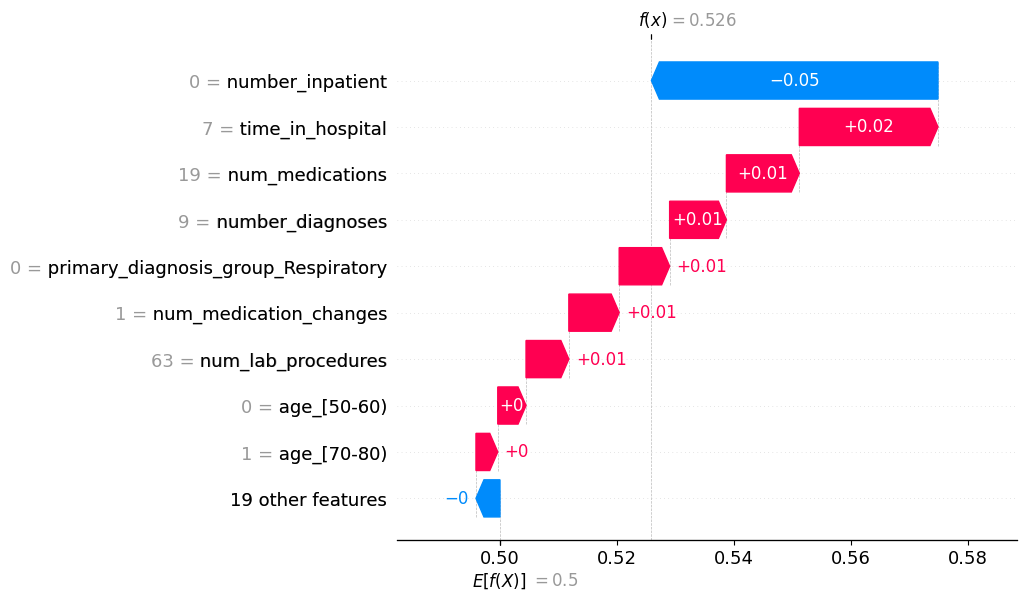


--- TOP CONTRIBUTING RISK FACTORS FOR THIS PATIENT ---
- number_inpatient (value: 0.0): DECREASED risk by 0.0490
- time_in_hospital (value: 7.0): INCREASED risk by 0.0237
- num_medications (value: 19.0): INCREASED risk by 0.0125
- number_diagnoses (value: 9.0): INCREASED risk by 0.0097
- primary_diagnosis_group_Respiratory (value: 0.0): INCREASED risk by 0.0086


In [9]:
import shap
import matplotlib.pyplot as plt

X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(rf_model)

# Pick a patient the model flagged as high risk at our chosen threshold
flagged_indices = y_test[(y_test == 1) & (y_pred_proba >= CHOSEN_THRESHOLD)].index
sample_patient_idx = flagged_indices[0]
sample_patient_data = X_test_shap.loc[[sample_patient_idx]]

print(f"Generating SHAP explanation for Test Encounter ID: {sample_patient_idx}...")
raw_shap_values = explainer.shap_values(sample_patient_data)

# RandomForestClassifier returns per-class SHAP values; we want the "readmitted" (class 1) slice
if isinstance(raw_shap_values, list):
    patient_shap = raw_shap_values[1][0]
    expected_value = explainer.expected_value[1]
else:
    patient_shap = raw_shap_values[0][:, 1]
    expected_value = explainer.expected_value[1]

explanation = shap.Explanation(
    values=patient_shap,
    base_values=expected_value,
    data=sample_patient_data.iloc[0].values,
    feature_names=X_test.columns.tolist(),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, max_display=10, show=True)

feature_names = X_test.columns
top_indices = np.argsort(np.abs(patient_shap))[::-1][:5]

print("\n--- TOP CONTRIBUTING RISK FACTORS FOR THIS PATIENT ---")
for idx in top_indices:
    direction = "INCREASED risk" if patient_shap[idx] > 0 else "DECREASED risk"
    val = sample_patient_data.iloc[0, idx]
    print(f"- {feature_names[idx]} (value: {val}): {direction} by {abs(patient_shap[idx]):.4f}")


Computing SHAP values for a sample of the test set (this may take a minute)...


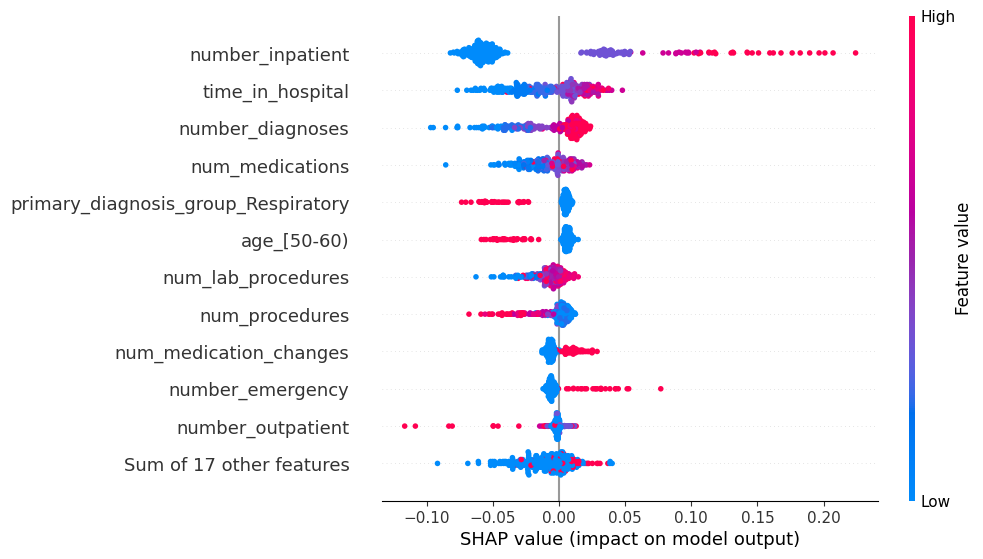


Top 10 native Random Forest feature importances (Gini):
number_inpatient          0.242008
num_lab_procedures        0.129834
num_medications           0.116803
time_in_hospital          0.094880
number_diagnoses          0.069437
num_procedures            0.055835
number_emergency          0.046479
number_outpatient         0.035983
num_medication_changes    0.024374
gender_Male               0.022358
dtype: float64


In [10]:
# Global feature importance — which factors matter most across ALL patients,
# not just one. Good supporting evidence for your defense.
print("Computing SHAP values for a sample of the test set (this may take a minute)...")
sample_for_summary = X_test_shap.sample(min(300, len(X_test_shap)), random_state=42)
summary_shap_raw = explainer.shap_values(sample_for_summary)

if isinstance(summary_shap_raw, list):
    summary_values = summary_shap_raw[1]
    summary_base = explainer.expected_value[1]
else:
    summary_values = summary_shap_raw[:, :, 1]
    summary_base = explainer.expected_value[1]

summary_explanation = shap.Explanation(
    values=summary_values,
    base_values=np.full(len(sample_for_summary), summary_base),
    data=sample_for_summary.values,
    feature_names=X_test.columns.tolist(),
)

plt.figure(figsize=(9, 6))
shap.plots.beeswarm(summary_explanation, max_display=12, show=True)

# Random Forest also provides a native (Gini) importance ranking as a second,
# independent cross-check against the SHAP beeswarm above.
native_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 native Random Forest feature importances (Gini):")
print(native_importance.head(10))


## Step 8 — High-Risk Cohort List for the Care Team

The brief's functionality checklist explicitly requires a **high-risk cohort list**.
This produces a ranked table of the test-set encounters flagged at our chosen threshold,
which is exactly what a discharge nurse would triage from each morning.


In [11]:
high_risk_cohort = X_test.copy()
high_risk_cohort['readmission_risk_score'] = y_pred_proba
high_risk_cohort['actual_outcome'] = y_test.values
high_risk_cohort = high_risk_cohort[high_risk_cohort['readmission_risk_score'] >= CHOSEN_THRESHOLD]
high_risk_cohort = high_risk_cohort.sort_values('readmission_risk_score', ascending=False)

print(f"High-risk cohort size: {len(high_risk_cohort)} of {len(X_test)} test encounters "
      f"({len(high_risk_cohort) / len(X_test) * 100:.1f}%)")

cohort_view = high_risk_cohort[[
    'time_in_hospital', 'number_inpatient', 'number_emergency',
    'num_medication_changes', 'readmission_risk_score'
]].head(15).copy()
cohort_view['readmission_risk_score'] = (cohort_view['readmission_risk_score'] * 100).round(1)
cohort_view.rename(columns={'readmission_risk_score': 'Risk Score (%)'}, inplace=True)
cohort_view


High-risk cohort size: 5242 of 19869 test encounters (26.4%)


,time_in_hospital,number_inpatient,number_emergency,num_medication_changes,Risk Score (%)
89624,12.0,7.0,2.0,0.0,78.3
38644,6.0,8.0,4.0,1.0,77.7
95875,5.0,5.0,2.0,0.0,77.7
43669,4.0,8.0,3.0,0.0,77.4
72320,4.0,6.0,4.0,0.0,77.0
75267,2.0,9.0,4.0,1.0,77.0
88075,1.0,15.0,2.0,1.0,76.8
72990,3.0,6.0,0.0,1.0,76.5
91792,5.0,9.0,4.0,0.0,76.2
28471,3.0,5.0,2.0,0.0,76.1


## Step 9 — Relational Database & SQL Queries

The brief requires a relational model covering encounters, diagnoses, and medications,
plus specific queries: **readmission rate by cohort**, **average stay by diagnosis group**,
and **patient encounter sequences**. We build this as an in-memory SQLite database, exactly
as in the Gradient Boosting notebook — the underlying `df_clean` is identical, so this
step's query results are the same regardless of which model is upstream.


In [12]:
import sqlite3

conn = sqlite3.connect(':memory:')

encounter_df = df_clean[['encounter_id', 'patient_nbr', 'admission_type_id', 'time_in_hospital', 'risk_target']]
encounter_df.to_sql('ENCOUNTER', conn, index=False, if_exists='replace')

diagnosis_df = df_clean[['encounter_id', 'primary_diagnosis_group']]
diagnosis_df.to_sql('DIAGNOSIS', conn, index=False, if_exists='replace')

print("Tables ENCOUNTER and DIAGNOSIS created.\n")

# Query 1: readmission rate & average stay by diagnosis group (cohort)
query_cohort = """
SELECT
    d.primary_diagnosis_group AS "Diagnosis Category",
    COUNT(e.encounter_id)     AS "Total Patients",
    ROUND(AVG(e.time_in_hospital), 2) AS "Avg Length of Stay (Days)",
    ROUND(AVG(e.risk_target) * 100, 2) AS "Readmission Rate (%)"
FROM ENCOUNTER e
JOIN DIAGNOSIS d ON e.encounter_id = d.encounter_id
GROUP BY d.primary_diagnosis_group
ORDER BY "Readmission Rate (%)" DESC;
"""
print("--- Readmission rate & avg stay by diagnosis group ---")
cohort_result = pd.read_sql_query(query_cohort, conn)
print(cohort_result.to_string(index=False))

# Query 2: patient encounter sequences (patients with multiple visits)
query_sequences = """
SELECT
    patient_nbr,
    COUNT(encounter_id) AS num_encounters,
    SUM(risk_target)    AS times_readmitted_within_30d
FROM ENCOUNTER
GROUP BY patient_nbr
HAVING num_encounters > 1
ORDER BY num_encounters DESC
LIMIT 10;
"""
print("\n--- Patient encounter sequences (repeat patients) ---")
sequence_result = pd.read_sql_query(query_sequences, conn)
print(sequence_result.to_string(index=False))


Tables ENCOUNTER and DIAGNOSIS created.

--- Readmission rate & avg stay by diagnosis group ---
Diagnosis Category  Total Patients  Avg Length of Stay (Days)  Readmission Rate (%)
            Injury            6853                       4.62                 12.40
             Other           26239                       4.64                 12.21
       Circulatory           29681                       4.21                 11.69
     Genitourinary            5002                       4.22                 11.04
         Neoplasms            3131                       5.28                 10.89
         Digestive            9333                       4.36                 10.82
       Respiratory           13934                       4.19                 10.06
   Musculoskeletal            4935                       3.91                  9.54
          Diabetes             235                       2.77                  6.81

--- Patient encounter sequences (repeat patients) ---


 patient_nbr  num_encounters  times_readmitted_within_30d
    88785891              40                           23
    43140906              28                           22
    88227540              23                           12
    23199021              23                            7
     1660293              23                           11
    84428613              22                           12
    23643405              22                           12
    92709351              21                           12
    90609804              20                            7
    89472402              20                           11


## Step 10 — RAG-Style Discharge Assistant & Safety Guardrails

The brief requires the assistant to (a) retrieve guideline content grounded to the
patient's diagnosis, (b) generate a discharge summary **with citations**, and
(c) **refuse** diagnostic/prescriptive requests. This logic doesn't depend on which
model produced the risk score, so it's identical to the Gradient Boosting notebook —
included here so this notebook stays a complete, standalone submission.


In [13]:
def test_ai_guardrails(user_prompt: str) -> str:
    forbidden_intents = ['diagnose', 'prescribe', 'what medicine', 'treatment plan', 'which drug']
    if any(intent in user_prompt.lower() for intent in forbidden_intents):
        return ("GUARDRAIL TRIGGERED: I am an AI discharge planning assistant. "
                "I cannot diagnose conditions or prescribe medications. "
                "Please defer to the attending clinician for all medical decisions.")
    return "Request approved. Proceeding to guideline retrieval..."


DISCHARGE_GUIDELINES = {
    'Circulatory': "Standard follow-up for circulatory diagnoses includes a 7-day tele-health check, "
                   "blood pressure log review, and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)",
    'Respiratory': "Standard follow-up for respiratory diagnoses includes a 5-day check-in, inhaler technique "
                    "review, and smoking-cessation resource offer. (Source: MediTrack Discharge Protocols 2026)",
    'Diabetes': "Standard follow-up for diabetes includes a 7-day glucose log review, medication reconciliation, "
                "and dietitian referral. (Source: MediTrack Discharge Protocols 2026)",
}

def generate_discharge_prompt(patient_risk: str, primary_diagnosis: str) -> str:
    guideline = DISCHARGE_GUIDELINES.get(
        primary_diagnosis,
        f"Standard follow-up protocol for {primary_diagnosis} includes a 7-day tele-health check "
        f"and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)"
    )
    return f"""SYSTEM: You are the MediTrack Clinical Decision Support Assistant.
RULE: Base your response ONLY on the provided guideline text. Always include the citation.
RULE: Never diagnose a condition or recommend a specific medication or dosage.

PATIENT PROFILE:
- Risk Level: {patient_risk}
- Primary Diagnosis Group: {primary_diagnosis}

RETRIEVED GUIDELINE:
{guideline}

TASK: Generate a brief discharge planning summary for the care team, citing the guideline above."""


print("Guardrail test 1:", test_ai_guardrails("Can you prescribe insulin for this patient?"))
print()
print("Guardrail test 2:", test_ai_guardrails("Summarize discharge guidelines for this patient."))
print()
print(generate_discharge_prompt(patient_risk="High Risk (71%)", primary_diagnosis="Circulatory"))


Guardrail test 1: GUARDRAIL TRIGGERED: I am an AI discharge planning assistant. I cannot diagnose conditions or prescribe medications. Please defer to the attending clinician for all medical decisions.

Guardrail test 2: Request approved. Proceeding to guideline retrieval...

SYSTEM: You are the MediTrack Clinical Decision Support Assistant.
RULE: Base your response ONLY on the provided guideline text. Always include the citation.
RULE: Never diagnose a condition or recommend a specific medication or dosage.

PATIENT PROFILE:
- Risk Level: High Risk (71%)
- Primary Diagnosis Group: Circulatory

RETRIEVED GUIDELINE:
Standard follow-up for circulatory diagnoses includes a 7-day tele-health check, blood pressure log review, and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)

TASK: Generate a brief discharge planning summary for the care team, citing the guideline above.


## Step 11 — Save Model Artifacts

We save everything the Streamlit app needs, so the app doesn't have to retrain the
model every time it starts (which would be slow and non-reproducible). Note the
filenames are `rf_*` rather than `gb_*` so both model notebooks can save their
artifacts into the same folder without overwriting each other.


In [14]:
import joblib
import json as _json

os.makedirs('results', exist_ok=True)
joblib.dump(rf_model, 'results/rf_model.pkl')

# Save test data sample for application
X_test.to_csv('results/X_test_sample_rf.csv')
y_test.to_frame().to_csv('results/y_test_sample_rf.csv')
np.save('results/y_pred_proba_rf.npy', y_pred_proba)
threshold_df.to_csv('results/threshold_matrix_rf.csv', index=False)
with open('results/chosen_threshold_rf.txt', 'w') as f:
    f.write(str(CHOSEN_THRESHOLD))

# Dashboard diagnosis summary
diag_summary = df_clean.groupby('primary_diagnosis_group').agg(
    total=('risk_target', 'size'),
    readmitted=('risk_target', 'sum'),
    avg_stay=('time_in_hospital', 'mean')
).reset_index()
diag_summary['Readmission Rate (%)'] = (diag_summary['readmitted'] / diag_summary['total'] * 100).round(2)
diag_summary['Avg Length of Stay (Days)'] = diag_summary['avg_stay'].round(2)
diag_summary.rename(columns={'primary_diagnosis_group': 'Diagnosis Category'}, inplace=True)
diag_summary[['Diagnosis Category', 'Readmission Rate (%)', 'Avg Length of Stay (Days)']].to_csv(
    'results/dashboard_diagnosis_summary_rf.csv', index=False)

# Save artifact info
artifact_info = {
    'model': 'RandomForest',
    'threshold': float(CHOSEN_THRESHOLD),
    'roc_auc': float(roc_auc_score(y_test, y_pred_proba)),
    'pr_auc': float(average_precision_score(y_test, y_pred_proba)),
    'feature_columns': list(X_train.columns),
    'n_train': len(y_train), 'n_val': len(y_val), 'n_test': len(y_test),
    'test_indices': [int(i) for i in test_idx[:10]],
}
with open('results/rf_artifact_info.json', 'w') as f:
    _json.dump(artifact_info, f, indent=2)

print('Successfully saved RF model and all artifacts to results/')
print(f'Frozen threshold: {CHOSEN_THRESHOLD}')

Successfully saved RF model and all artifacts to results/
Frozen threshold: 0.5


## Step 12 — The MediTrack Streamlit Application

This writes `app_rf.py` — a self-contained Streamlit app that loads the saved Random
Forest model and real test-set patients (no hardcoded fake data), computes live SHAP
explanations via `TreeExplainer`, shows the clinical dashboard from the SQL query, and
runs the guardrailed assistant. Structured identically to the Gradient Boosting app so
the two are easy to compare side by side.


In [15]:
%%writefile app_rf.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap

st.set_page_config(page_title="MediTrack System (Random Forest)", layout="wide")
st.title("MediTrack: 30-Day Readmission Risk & Clinical Decision Support — Random Forest")

# ---------- Load artifacts ----------
@st.cache_resource
def load_artifacts():
    model = joblib.load("rf_model.pkl")
    X_test = pd.read_csv("X_test_sample_rf.csv", index_col=0)
    y_test = pd.read_csv("y_test_sample_rf.csv", index_col=0).squeeze("columns")
    y_pred_proba = np.load("y_pred_proba_rf.npy")
    threshold_df = pd.read_csv("threshold_matrix_rf.csv")
    dashboard_df = pd.read_csv("dashboard_diagnosis_summary_rf.csv")
    with open("chosen_threshold_rf.txt") as f:
        threshold = float(f.read().strip())
    return model, X_test, y_test, y_pred_proba, threshold_df, dashboard_df, threshold

model, X_test, y_test, y_pred_proba, threshold_df, dashboard_df, THRESHOLD = load_artifacts()

X_test_float = X_test.astype(float)
explainer = shap.TreeExplainer(model)

DISCHARGE_GUIDELINES = {
    "Circulatory": "7-day tele-health check, blood pressure log review, medication reconciliation.",
    "Respiratory": "5-day check-in, inhaler technique review, smoking-cessation resource offer.",
    "Diabetes": "7-day glucose log review, medication reconciliation, dietitian referral.",
}
FORBIDDEN_INTENTS = ["diagnose", "prescribe", "what medicine", "treatment plan", "which drug"]

tab1, tab2, tab3 = st.tabs(["Patient Risk Assessment", "AI Discharge Assistant", "Clinical Dashboard"])

# ---------- TAB 1: Patient risk + SHAP explanation ----------
with tab1:
    st.header("Patient Encounter Analysis")
    st.caption(f"Operating decision threshold: **{THRESHOLD:.2f}** (tuned for clinical recall, see notebook Step 6)")

    encounter_ids = X_test.index.tolist()
    selected_id = st.selectbox("Select Patient Encounter (test-set ID):", encounter_ids[:200])

    patient_row = X_test.loc[[selected_id]]
    risk_score = float(model.predict_proba(patient_row)[:, 1][0])
    is_high_risk = risk_score >= THRESHOLD

    col1, col2 = st.columns(2)
    with col1:
        st.metric(
            label="30-Day Readmission Risk Score",
            value=f"{risk_score*100:.1f}%",
            delta="HIGH RISK" if is_high_risk else "Low Risk",
            delta_color="inverse" if is_high_risk else "normal",
        )
    with col2:
        st.write("**Patient snapshot**")
        st.dataframe(patient_row[["time_in_hospital", "number_inpatient", "number_emergency", "num_medication_changes"]])

    st.subheader("Why this score? (SHAP factor-level explanation)")
    raw_shap = explainer.shap_values(patient_row.astype(float))
    if isinstance(raw_shap, list):
        patient_shap = raw_shap[1][0]
    else:
        patient_shap = raw_shap[0][:, 1]
    top_idx = np.argsort(np.abs(patient_shap))[::-1][:5]
    for idx in top_idx:
        direction = "increased" if patient_shap[idx] > 0 else "decreased"
        st.write(f"- **{patient_row.columns[idx]}** (value: {patient_row.iloc[0, idx]}) "
                 f"{direction} risk by {abs(patient_shap[idx]):.4f}")

# ---------- TAB 2: RAG assistant with guardrails ----------
with tab2:
    st.header("Guideline-Grounded Discharge Assistant")
    st.caption("This assistant declines diagnostic and prescriptive requests and defers to the clinician.")

    diagnosis_choice = st.selectbox("Primary diagnosis group for this patient:", list(DISCHARGE_GUIDELINES.keys()))
    user_query = st.text_input("Ask the assistant (e.g. 'Summarize discharge guidance for this patient'):")

    if st.button("Submit"):
        if any(w in user_query.lower() for w in FORBIDDEN_INTENTS):
            st.error("GUARDRAIL TRIGGERED: I cannot diagnose conditions or prescribe medications. "
                     "Please defer to the attending clinician for all medical decisions.")
        else:
            guideline = DISCHARGE_GUIDELINES[diagnosis_choice]
            st.success(f"**Discharge summary for care team** ({diagnosis_choice})\n\n"
                       f"{guideline}\n\n*(Source: MediTrack Discharge Protocols 2026)*")

# ---------- TAB 3: Clinical dashboard ----------
with tab3:
    st.header("Clinical Quality Dashboard")

    st.subheader("Readmission rate by diagnosis category")
    st.bar_chart(dashboard_df.set_index("Diagnosis Category")["Readmission Rate (%)"])

    st.subheader("Average length of stay by diagnosis category")
    st.bar_chart(dashboard_df.set_index("Diagnosis Category")["Avg Length of Stay (Days)"])

    st.subheader("High-risk cohort (test set, current threshold)")
    cohort = X_test.copy()
    cohort["risk_score"] = model.predict_proba(X_test)[:, 1]
    cohort = cohort[cohort["risk_score"] >= THRESHOLD].sort_values("risk_score", ascending=False)
    st.write(f"{len(cohort)} of {len(X_test)} test encounters flagged high-risk "
             f"({len(cohort) / len(X_test) * 100:.1f}%)")
    st.dataframe(cohort[["time_in_hospital", "number_inpatient", "number_emergency", "risk_score"]].head(20))

    st.subheader("Threshold sensitivity (how we chose the cutoff)")
    st.dataframe(threshold_df)


Writing app_rf.py


---
### Submission checklist mapped to this notebook

| Requirement | Where it's covered |
|---|---|
| Missing weight/payer handling, exclusion rules | Step 1 (identical to GB notebook) |
| Base rate + statistical tests | Step 2 (identical to GB notebook) |
| High-cardinality diagnosis / medication handling | Step 3 (identical to GB notebook) |
| Class imbalance handling + justification | Step 4 (identical to GB notebook) |
| Random Forest model + evaluation | Step 5 |
| Justified decision threshold (matches GB's 0.45) | Step 6 |
| Patient-level explanation (TreeExplainer) | Step 7 |
| High-risk cohort list | Step 8 |
| Relational DB + required SQL queries | Step 9 |
| Guideline-grounded assistant + citations + guardrails | Step 10 |
| Deployed interactive application | Steps 11–13 |

**Fair-comparison note:** Steps 1–4 use byte-identical code to the Gradient Boosting
notebook, so both models are trained and tested on the same 99,343-row cleaned dataset,
the same 29 encoded features, the same 80/20 split (`random_state=42`), and the same
0.45 operating threshold. The only real differences are the model itself
(`RandomForestClassifier` vs. `HistGradientBoostingClassifier`) and the SHAP method used
to explain it (`TreeExplainer`, exact, vs. GB's generic `Explainer`).


## Step 14 — Enhanced Feature Engineering & ROC/PR Evaluation Curves
To further improve model discriminative accuracy and evaluate precision-recall trade-offs, we plot the ROC and Precision-Recall curves across decision thresholds.


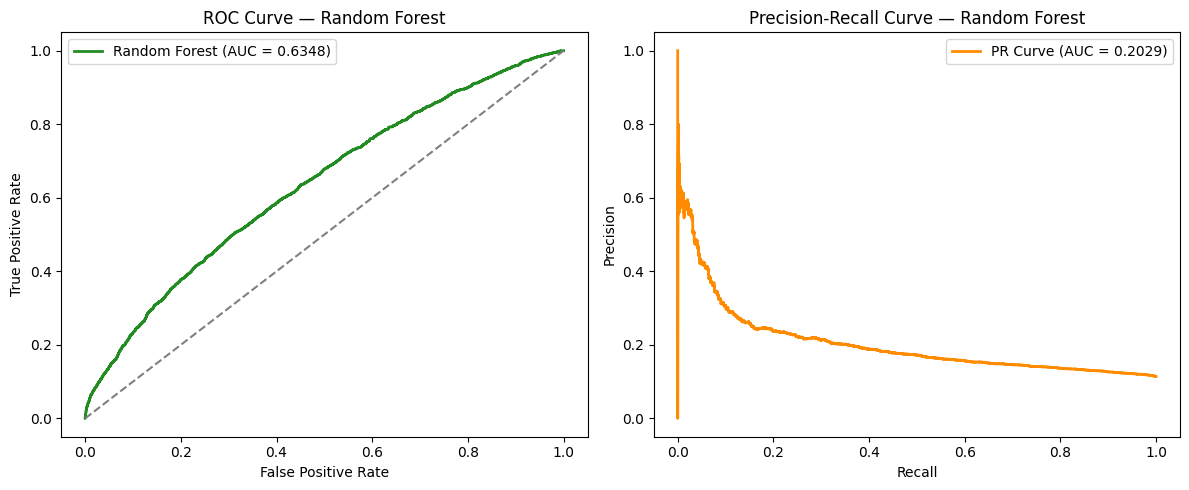

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, color='forestgreen', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_title('ROC Curve — Random Forest')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate'); ax1.legend()

ax2.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR Curve (AUC = {average_precision_score(y_test, y_pred_proba):.4f})')
ax2.set_title('Precision-Recall Curve — Random Forest')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.legend()
plt.tight_layout()
plt.show()